In [ ]:
!pip install langchain-google-genai langchain_tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.4 MB/s eta 0:00:00


# **Re-Act Agent**

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image,display
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
import os
os.environ["LANGSMITH_API_KEY"] ="xxxxxxxxxxxxx"

os.environ["LANGSMITH_TRACING"] = "true"

os.environ["LANGSMITH_PROJECT"]="your_project_name"

os.environ['GEMINI_API_KEY']="xxxxxxxxxxxxxxxx"

os.environ["TAVILY_API_KEY"] = "xxxxxxxxxxxxxxxx"

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm= ChatGoogleGenerativeAI(model= "gemini-2.5-flash",
                            temperature=0.4
                             )

In [ ]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

In [ ]:
@tool
def multiply(a:int,b:int):
  """Multiply a and b
  Args:
      a (int): first int
      b (int): second int
  Returns:
      int: output int
   """

  return a*b

In [ ]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(max_results=3)

tools=[search_tool,multiply]

llm_with_tool=llm.bind_tools(tools)

In [ ]:
memory = MemorySaver()

config={"configurable":{"thread_id":"1"}}

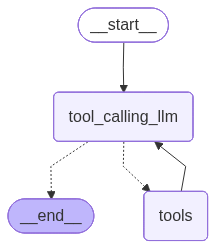

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state:State):
  return {"messages":[llm_with_tool.invoke(state["messages"])]}

#nodes
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")

#COMPILE
graph=builder.compile(checkpointer=memory)

#GRAPH VISUALIZATION
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
res = graph.invoke({"messages":"hello, my name is raj tembe"},config=config)
for r in res['messages']:
  r.pretty_print()

================================ Human Message =================================

hello, my name is raj tembe
================================== Ai Message ==================================

Hello Raj, how can I help you?


In [14]:
res = graph.invoke({"messages":"what is my name?, "},config=config)
for r in res['messages']:
  r.pretty_print()

================================ Human Message =================================

hello, my name is raj tembe
================================== Ai Message ==================================

Hello Raj, how can I help you?
================================ Human Message =================================

hey what is my name
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Your name is Raj Tembe.', 'extras': {'signature': 'Cv4BAQw51sdPdf8JHpc4uO6NsFi5AkPIW7Hbu1UNpXrUmLfrReuHklLiuCn/4sv/a+QAUfeLN/ZP0rsPn755/0nqjHGTt2TsnBuaWsvvgasx7008NYlmrkrWPJQzEHDhAAfhcDQwts5/+eIkYHKxFzsh/R+tQ40BQz9BA5QREpp+xeKlltuvTKmsVnNRZu2Q2dADrz9VW1J3DTPFC4/GKIigWfhhI6ihsUHolCm38rHDLkzTN/XGSJdIcJME7+L39+j6/9h8V4mEVREPZcZVT7vxJMzzzeBpnforvMHrp28+yt4ODNoE0jXr61rJbmggiuNIyEyZL4kPc55DiKBA+6M='}}]
================================ Human Message =================================

hey what is my name
================================== Ai Message ==================

In [15]:
res = graph.invoke({"messages":"create an article on wild life conservation with referencing lattest events."},config=config)
for r in res['messages']:
  r.pretty_print()

================================ Human Message =================================

hello, my name is raj tembe
================================== Ai Message ==================================

Hello Raj, how can I help you?
================================ Human Message =================================

hey what is my name
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Your name is Raj Tembe.', 'extras': {'signature': 'Cv4BAQw51sdPdf8JHpc4uO6NsFi5AkPIW7Hbu1UNpXrUmLfrReuHklLiuCn/4sv/a+QAUfeLN/ZP0rsPn755/0nqjHGTt2TsnBuaWsvvgasx7008NYlmrkrWPJQzEHDhAAfhcDQwts5/+eIkYHKxFzsh/R+tQ40BQz9BA5QREpp+xeKlltuvTKmsVnNRZu2Q2dADrz9VW1J3DTPFC4/GKIigWfhhI6ihsUHolCm38rHDLkzTN/XGSJdIcJME7+L39+j6/9h8V4mEVREPZcZVT7vxJMzzzeBpnforvMHrp28+yt4ODNoE0jXr61rJbmggiuNIyEyZL4kPc55DiKBA+6M='}}]
================================ Human Message =================================

hey what is my name
================================== Ai Message ==================